**This notebook presents a simple example of the `umbra` transit search code version 1.0.0.**

In [1]:
import umbra

%matplotlib inline
import matplotlib.pyplot as plt

For this example notebook we use a simulated light curve included with `umbra`. The light curve contains a transit around a Sun-like star.

In [2]:
lc = umbra.load_test_data('sim-lc-circular.asdf')

The lightcurve is saved in an `asdf` file. We can inspect the contents like so:

In [3]:
lc.info(max_rows=None)

root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): The ASDF Developers
│ ├─homepage (str): http://github.com/asdf-format/asdf
│ ├─name (str): asdf
│ └─version (str): 5.3.0
├─history (dict)
│ └─extensions (list)
│   └─[0] (ExtensionMetadata)
│     ├─extension_class (str): asdf.extension._manifest.ManifestExtension
│     ├─extension_uri (str): asdf://asdf-format.org/core/extensions/core-1.6.0
│     ├─manifest_software (Software)
│     │ ├─name (str): asdf_standard
│     │ └─version (str): 1.5.0
│     └─software (Software)
│       ├─name (str): asdf
│       └─version (str): 5.3.0
├─data (dict)
│ ├─flux (NDArrayType)
│ │ ├─shape (tuple)
│ │ │ └─[0] (int): 25920
│ │ └─dtype (Float64DType): float64
│ ├─flux_err (NDArrayType)
│ │ ├─shape (tuple)
│ │ │ └─[0] (int): 25920
│ │ └─dtype (Float64DType): float64
│ ├─time (NDArrayType)
│ │ ├─shape (tuple)
│ │ │ └─[0] (int): 25920
│ │ └─dtype (Float64DType): float64
│ └─trend (NDArrayType)
│   ├─shape (tuple)
│   │ └─[0] (int): 25920
│   └─

The *data* section contains the observation times, flux values and uncertainties as well as the result of running a trend filter on the data. The *header* section contains the parameters on the simulated *observation*, the *stellar* and *transit* parameters and finally information on the *trend_filter* used to generate the *trend* field in the data section. We will not use the trend in this example. 

Let's unpack parts of the data for easier access.

In [4]:
# Unpack the sections.
obs_pars = lc['header']['observation']
stellar_pars = lc['header']['stellar']
transit_pars = lc['header']['transit']

# Unpack the light curve fields.
time = lc['data']['time']
flux = lc['data']['flux']
flux_err = lc['data']['flux_err']

Let's take a look at the simulated lightcurve as a function of time and observation phase.

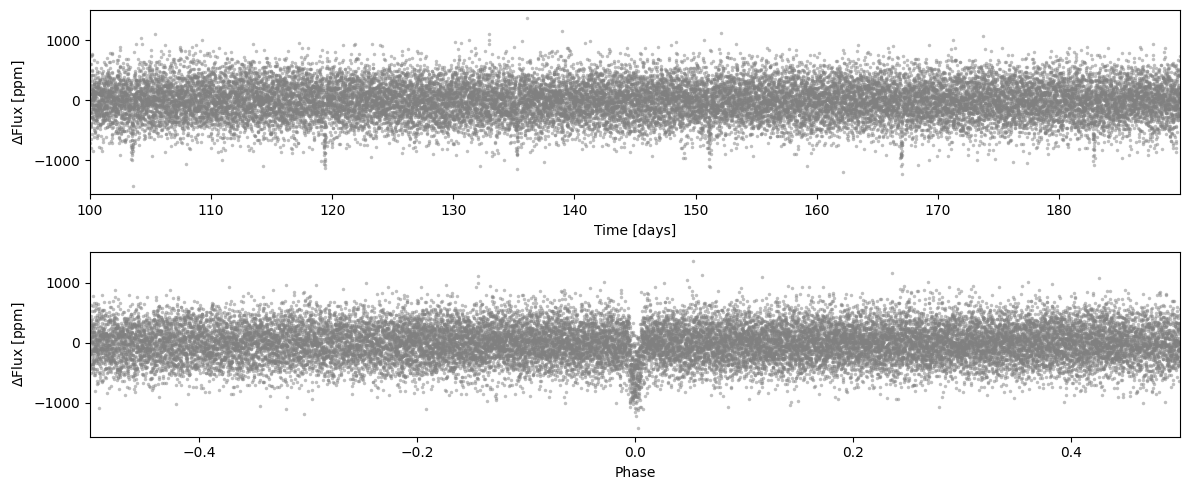

In [5]:
# Compute the folded-phase, centering the transit at phase zero.
phase = umbra.phase_fold(time, transit_pars['period'], transit_pars['epoch'])

# Plot the lightcurve as a function of time and phase.
plt.figure(figsize=(12, 5))

ax = plt.subplot(211)

plt.plot(time, 1e6 * (flux - 1), '.', markersize=5, markeredgecolor='None', alpha=0.5, color='gray')
plt.xlim(time[0], time[-1])

plt.xlabel('Time [days]')
plt.ylabel(r'$\Delta$Flux [ppm]')

plt.subplot(212, sharey=ax)

plt.plot(phase, 1e6 * (flux - 1), '.', markersize=5, markeredgecolor='None', alpha=0.5, color='gray')
plt.xlim(-0.5, 0.5)

plt.xlabel('Phase')
plt.ylabel(r'$\Delta$Flux [ppm]')

plt.tight_layout()

We're now ready to perform the transit search. We start by creating in instance of the TransitSearch class and setting the perioogram normalisation and the spacing of the duration grid. All target independent parameters of the search are set here.

In [6]:
ts = umbra.TransitSearch(
    period_sampling=1,  # WARNING: we use a value of 1 for demonstration purposes only.
    normalisation='umbra',  # Use the 'umbra' normalisation for the periodogram power.
    frac_duration_step=1.15,  # Set the duration sampling.
)

Next we perform a transit least-squares (TLS) search. All target specific parameters are set here.

In [7]:
search_result = ts.transit_lstsq(
    time,  # The lightcurve.
    flux,
    flux_err,
    obs_pars['exp_time'],  # The observational parameters.
    obs_pars['exp_cadence'],
    min_stellar_radius=0.8*stellar_pars['radius'],  # A range of stellar parameters around the true values.
    max_stellar_radius=1.2*stellar_pars['radius'],
    min_stellar_mass=0.8*stellar_pars['mass'],
    max_stellar_mass=1.2*stellar_pars['mass'],
    ld_type=transit_pars['ld_type'],  # We use the true limb-darkening for this example search.
    ld_pars=transit_pars['ld_pars'],
)

The returned result is an asdf file tree. If we had provided a value for `output_file` to `transit_lstsq` an asdf file would been written to disk. Let's take a look at the contents of the file with the asdf `info` method.

In [8]:
search_result.info(max_rows=None, show_values=False)

root (AsdfObject)
├─config (dict)
│ ├─global (dict)
│ │ ├─version (str)
│ │ ├─min_transits (int)
│ │ ├─min_separation (float)
│ │ ├─period_sampling (int)
│ │ ├─min_period (NoneType)
│ │ ├─max_period (NoneType)
│ │ ├─epoch_sampling (int)
│ │ ├─min_epoch_step (float)
│ │ ├─max_epoch_step (float)
│ │ ├─circular_orbits (bool)
│ │ ├─frac_eccentricity (float)
│ │ ├─frac_duration_step (float)
│ │ ├─period_group_sampling (int)
│ │ ├─normalisation (str)
│ │ └─num_processes (NoneType)
│ └─target (dict)
│   ├─templates (str)
│   ├─exp_time (float)
│   ├─exp_cadence (float)
│   ├─min_stellar_radius (float)
│   ├─max_stellar_radius (float)
│   ├─min_stellar_mass (float)
│   ├─max_stellar_mass (float)
│   ├─ld_type (str)
│   └─ld_pars (ndarray)
│     ├─shape (tuple)
│     │ └─[0] (int)
│     └─dtype (Float64DType)
└─search (dict)
  ├─header (dict)
  │ ├─runtime (float)
  │ ├─chisq0 (float64)
  │ ├─lc_size (int)
  │ ├─baseline (float64)
  │ ├─periods (ndarray)
  │ │ ├─shape (tuple)
  │ │ │ └─[0] (int

The file consist of two main parts *config*, which contains all input parameters to umbra, and *search* which contains the search results. *config* further consists of *global*, the parameters passed when initilizaing the `TransitSearch` class, and *target* the parameters passed to the `transit_lstsq` call. *search* is divided into the *header*, which contains the period and duration grid, as well as information on the period groups used. Finally, *circular* contains the returned *periodogram*, and the best-fit *transit_model*.

Finally we plot the search result. In the top panel we show the periodogram power which is defined to be normalised between 0 and 1. The bottom panel shows the lightcurve phase-folded to the recovered period and epoch, together with the transit template used in the detection. We can see the discrete nature of the transit template employed by `umbra`.

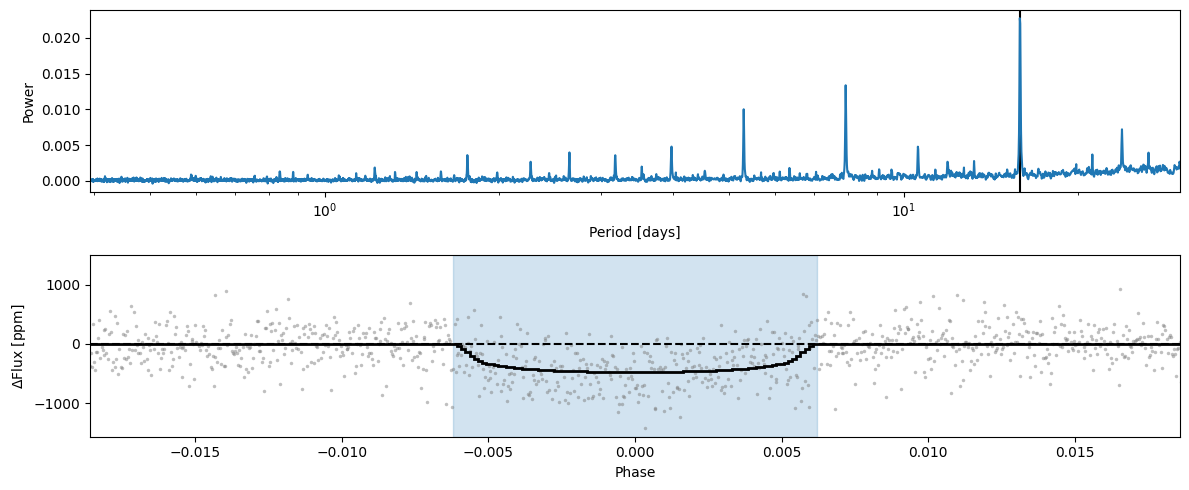

In [9]:
# Unpack parts of the tree.
periodogram = search_result['search']['circular']['periodogram']  # Search result periodogram.
transit_model = search_result['search']['circular']['transit_model']  # Best-fit transit model.

# Use the quick look diagnostic plot.
umbra.plot_quick_look(time, flux, periodogram, transit_model)